In [1]:
%load_ext autoreload
%autoreload 2
 
import operator
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')

from notebooks.experiment2 import Plan
from runtime.v4.semantics.load_semantics import load_semantics, load_idiom_rules
from runtime.v4.semantics.semantic_models import * 
from runtime.v4.analyst_agent.catalog import Catalog
from runtime.v4.analyst_agent.smart_data import SmartData
from runtime.v4.analyst_agent.smart_data_tools  import SmartDataTools
from runtime.v4.analyst_agent.analyst_models  import *
from runtime.v4.analyst_agent.analyst_prompts import system_prompt_template3 as agent_system_prompt


import  os  
from datetime import datetime 
from langchain_core.tools import StructuredTool, Tool

from langgraph.graph import StateGraph, END

import duckdb
from typing import Annotated, Any, Dict, List, Iterable, TypedDict, TypedDict, Union, Optional 
import yaml
import pprint
import pandas as pd, numpy as np
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig, Runnable, RunnableLambda
 
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
from langchain_core.runnables import RunnableLambda
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from langchain_core.runnables import Runnable
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import get_runtime 
from langchain.agents import create_agent
 
 
from get_llm_model import azure_llm_if

class SystemTask(BaseModel):
    tool: Literal[
        "analyst_agent",
        "explanation_rag",
        "general_knowledge_agent",
        "project_structure_agent",
        "information_request",
        "derive_from_context"
    ] = Field(
        description="The specific domain expert agent assigned to execute this task phase."
   )

    instruction: str = Field(
      description=(
            "The comprehensive, high-level objective for this agent phase. "
            "Do NOT break down sub-steps, intermediate calculations, or plotting adjustments. "
            "Provide the complete end-goal description verbatim so the receiving agent "
            "can handle its own internal execution steps."
        )
    )

class SystemPlan(BaseModel):
    
    agent: Literal["planner"] = Field(
        description="Fixed identifier for the planner agent."
    )

    user_intent: str = Field(
        description="One-sentence summary of the user's ultimate goal."
    )

    tasks: List[SystemTask] = Field(
          description=(
            "The macro-level pipeline. Create exactly ONE task per required agent domain. "
            "Only include multiple tasks if the user query explicitly demands cross-domain "
            "hand-offs (e.g., fetching project structure metadata BEFORE running an analysis)."
        ))

class ToolOutput(BaseModel):
    tool: str
    instruction: str
    output: Any

class ExecutorState(TypedDict):
    # Current turn
    user_query: str
    plan: SystemPlan | None
    task_index: int
    aggregated_context: str | None
    final_answer: str | None

    # Accumulated fields
    tool_outputs: Annotated[list[ToolOutput], operator.add]
    general_knowledge: Annotated[list[str], operator.add]
    facts: Annotated[list[str], operator.add]


imported


In [2]:
import sys, pathlib, json, pprint, pandas as pd 
from pathlib import Path
from pydantic import Field,BaseModel 
sys.path.append('../../')
sys.path.append('../')
sys.path.append('./')


from get_llm_model import azure_llm_if

llm = azure_llm_if()
print(llm)
#from experiment2 import *  

zero temp, seed 42, top_p = 1
client=<openai.resources.chat.completions.completions.Completions object at 0x0000023485A50970> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000234AFC2EC80> root_client=<openai.lib.azure.AzureOpenAI object at 0x0000023485A53100> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000023485A50910> model_name='gpt-4.1' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') stream_usage=True seed=42 top_p=1.0 disabled_params={'parallel_tool_calls': None} azure_endpoint='https://openai-if-test.openai.azure.com/' deployment_name='gpt-4' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [3]:
def planner_node(state: ExecutorState,llm) -> dict:
    return {}
def executor_node(state: ExecutorState, llm) -> dict:
    return {}
def analyst_node(state: ExecutorState, llm) -> dict:
    return {}
def project_structure_node(state: ExecutorState, llm) -> dict:
    return {}
def general_knowledge_node(state: ExecutorState, llm) -> dict:
    return {}
def derive_from_context_node(state: ExecutorState, llm) -> dict:
    return {}
def presenter_node(state: ExecutorState, llm) -> dict:
    return {}
def explanation_rag_node(state: ExecutorState, llm) -> dict:
    return {}
def information_request_node(state: ExecutorState, llm) -> dict:
    return {}
def aggregator_node(state: ExecutorState, llm) -> dict:
    return {}
def route_next_task(state: ExecutorState) -> str:
    return "" 

In [4]:


from functools import wraps

def make_llm_calling_node(node, llm):
    @wraps(node)
    def wrapped_node(state):
        return node(state, llm=llm)

    return wrapped_node

graph = StateGraph(ExecutorState)

graph.add_node("planner", make_llm_calling_node(planner_node, llm))
graph.add_node("executor", executor_node)

graph.add_node("analyst_agent", analyst_node)
graph.add_node("general_knowledge_agent", general_knowledge_node)
graph.add_node("project_structure_agent", project_structure_node)
graph.add_node("explanation_rag", explanation_rag_node)
graph.add_node("information_request", information_request_node)
graph.add_node("derive_from_context", derive_from_context_node)

graph.add_node("aggregator", aggregator_node)
graph.add_node("presenter", make_llm_calling_node(presenter_node, llm))

graph.set_entry_point("planner")

graph.add_edge("planner", "executor")

graph.add_conditional_edges(
    "executor",
    route_next_task,
    {
        "analyst_agent": "analyst_agent",
        "general_knowledge_agent": "general_knowledge_agent",
        "project_structure_agent": "project_structure_agent",
        "explanation_rag": "explanation_rag",
        "information_request": "information_request",
        "derive_from_context": "derive_from_context",
        "aggregate": "aggregator",
    },
)

for node_name in [
    "analyst_agent",
    "general_knowledge_agent",
    "project_structure_agent",
    "explanation_rag",
    "information_request",
    "derive_from_context",
]:
    graph.add_edge(node_name, "executor")

graph.add_edge("aggregator", "presenter")
graph.add_edge("presenter", END)

executor_app = graph.compile()


In [6]:
from IPython.display import Markdown, display

mermaid = executor_app.get_graph().draw_mermaid()
mermaid = mermaid.replace("graph TD", "graph LR")
mermaid = mermaid.replace("flowchart TD", "flowchart LR")

display(Markdown(f"```mermaid\n{mermaid}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph LR;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	executor(executor)
	analyst_agent(analyst_agent)
	general_knowledge_agent(general_knowledge_agent)
	project_structure_agent(project_structure_agent)
	explanation_rag(explanation_rag)
	information_request(information_request)
	derive_from_context(derive_from_context)
	aggregator(aggregator)
	presenter(presenter)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	aggregator --> presenter;
	analyst_agent --> executor;
	derive_from_context --> executor;
	executor -. &nbsp;aggregate&nbsp; .-> aggregator;
	executor -.-> analyst_agent;
	executor -.-> derive_from_context;
	executor -.-> explanation_rag;
	executor -.-> general_knowledge_agent;
	executor -.-> information_request;
	executor -.-> project_structure_agent;
	explanation_rag --> executor;
	general_knowledge_agent --> executor;
	information_request --> executor;
	planner --> executor;
	project_structure_agent --> executor;
	presenter --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

In [5]:



# ============================================================
# Run graph
# ============================================================

initial_state: ExecutorState = {
    "user_query": "Compare oil production by producer for 2023.",

    "plan": None,
    "task_index": 0,
    "aggregated_context": None,
    "final_answer": None,

    "tool_outputs": [],
    "general_knowledge": [],
    "facts": [],
}

result = executor_app.invoke(initial_state)

print("FINAL ANSWER:")
print(result["final_answer"])

result

TypeError: executor_node() missing 1 required positional argument: 'llm'

In [6]:
executor_prompt1 = """
You are the PLANNER AGENT.

===============================================================================
Your responsibilities:
===============================================================================
1. Understand the user’s request and clarify the underlying intent.
2. Convert a user’s request into an explicit execution plan or, when appropriate, a direct answer.

====================================================
TASK TYPES
====================================================
- "analyst_agent"  → useful for multi-step and complex analytical queries on project injection and production data. 
  The analyst can decompose complex analytical queries into multiple steps, each producing 
  intermediate context that feeds into the next, ultimately leading to the final answer.

  Example 1: 'Plot the cummulated oil production over the cummulated water injected per subzone in 2020" 
  Example 2: 'Plot the WOR over the cummulated oil production for the top 5 producers. Plot each well in a different color and include a legend. ' 
  Example 3: 'Compare the total liquid production of wells grouped by the distance to their 
  closest injector well, using the following intervals: 0–500 meters, 500–1,000 meters, 
  and 1,000–1,500 meters.'
  

-"explanation_rag" → conceptual or theoretical explanation related to waterflooding in the \
    context of reservoir engineering or reservoir engineering in general. 
    Example: 'Whats GOR?'
    Example: "How can I interpret a Hall plot?"
    Example: "What analysis can I do to check if there is a risk of hydraulic fracturing tthe rock" 

    - "general_knowledge_agent"  → general factual knowledge (non-project-specific). 
    Example: 'Whats the density of water?'
    Example: 
- "project_structure_agent" → returns information on the project structure, well hierarchical 
   distribution, well count, simulation count. The agent cannot produce quantitative analysis but can return counts, 
   lists, distributions related to the project structure.
   Example 1: '1: Whats the distribution of wells across subzones in project X?'. 
   Example 2: 'How many simulations are in the project?'
   Example 3: 'Describe the project'


   - "derive_from_context" → derive a specific fact from previously produced context (LLM-only, no data access)
- "information_request" → ask the user for missing information (terminal)

====================================================
TASK ORDERING RULES
====================================================
- Tasks MUST be ordered in the exact sequence they should be executed.
- Context-producing tasks must come before tasks that consume them.
- If a task depends on prior results, you MUST either:
  - use "derive_from_context", or
  - make the dependency explicit in the instruction.
- General knowledge or explanations come before data queries.
- Project structure tasks come before analytical computations.
- Analytical tasks (analyst_agent) come last.
- Do NOT merge tasks that belong to different categories. Use multiple tasks when steps are sequential.
- Do NOT assume implicit dependencies.
"""

executor_prompt2 = """
You are the PLANNER AGENT.

===============================================================================
Your responsibilities:
===============================================================================
1. Understand the user’s request and clarify the underlying intent.
2. Routing & Orchestration: Map the user's high-level request to the correct agent(s).
3. Do NOT over-decompose analytical tasks. If a query requires complex data manipulation, routing it to the "analyst_agent" as a single, consolidated task is sufficient. The Analyst Agent will handle its own internal multi-step breakdown.

====================================================
TASK TYPES
====================================================
- "analyst_agent"  → Useful for complex, multi-step analytical queries on project injection and production data.
  CRITICAL: Delegate the entire analytical goal to this agent as a single task. Do not break down the math, plotting steps, or data filtering into separate Planner tasks.
  
  Example 1: 'Plot the cummulated oil production over the cummulated water injected per subzone in 2020' 
  Example 2: 'Plot the WOR over the cummulated oil production for the top 5 producers. Plot each well in a different color and include a legend.' 
  Example 3: 'Compare the total liquid production of wells grouped by the distance to their closest injector well, using the following intervals: 0–500 meters, 500–1,000 meters, and 1,000–1,500 meters.'

- "explanation_rag" → Conceptual or theoretical explanation related to waterflooding or reservoir engineering in general.
  Example 1: 'Whats GOR?'
  Example 2: 'How can I interpret a Hall plot?'
  Example 3: 'What analysis can I do to check if there is a risk of hydraulic fracturing the rock?' 

- "general_knowledge_agent" → General factual knowledge (non-project-specific). 
  Example: 'Whats the density of water?'

- "project_structure_agent" → Returns metadata on project structure, well hierarchical distribution, well/simulation counts. Cannot produce quantitative data analysis.
  Example 1: 'Whats the distribution of wells across subzones in project X?'
  Example 2: 'How many simulations are in the project?'
  Example 3: 'Describe the project structure'

- "derive_from_context" → Derive a specific fact from previously produced context (LLM-only, no data access).
- "information_request" → Ask the user for missing information (terminal task).

====================================================
TASK ORDERING & GRANULARITY RULES
====================================================
1. Macro-Level Sequencing Only: Order tasks sequentially ONLY when crossing different agent domains (e.g., Explain a concept first, fetch metadata second, run analysis last).
2. High-Level Delegation: Pass analytical requests to the "analyst_agent" as one unified objective. Never generate sequential "analyst_agent" tasks for a single user query.
3. Context Ordering: General knowledge/explanations come before project structure tasks. Project structure tasks come before analytical computations.
4. Do NOT assume implicit dependencies or merge tasks belonging to completely different categories.
"""

executor_prompt3 = """
You are the PLANNER AGENT. Your sole responsibility is architectural routing: mapping the user's high-level request to the appropriate specialized domain agents.

===============================================================================
THE DOMAIN BOUNDARY PRINCIPLE
===============================================================================
- You operate at a macro-level. A 'Task' represents a hand-off to an entire domain, NOT an individual procedural step.
- Trust downstream agents: Downstream agents (especially the analyst_agent) are fully autonomous and contain their own internal planners. Deliver the complete objective to them as a single consolidated instruction.
- Only chain multiple tasks if the query fundamentally spans different knowledge domains in a strict waterfall sequence.

===============================================================================
DOMAIN EXPERTS (TOOL SELECTION)
===============================================================================
- "analyst_agent": Raw Data Analytics
  * Scope: Calculations, data processing, metrics comparison, aggregations, and plotting on production/injection data.
  * Constraint: Pass the full analytical goal as one unified block.

- "explanation_rag": Domain Theory
  * Scope: Conceptual or theoretical explanations regarding reservoir engineering or waterflooding.

- "general_knowledge_agent": Public Fact Checking
  * Scope: Project-agnostic scientific constants or baseline units (e.g., water density).

- "project_structure_agent": Project Inventory & Metadata
  * Scope: Well counts, simulation distributions, hierarchy metadata. Cannot perform mathematical analysis.

- "derive_from_context": Context Reasoning
  * Scope: Summarizing or extracting facts strictly from previous chat turns. No tool data access.

- "information_request": User Interaction
  * Scope: Missing parameters required before any execution can safely start.

===============================================================================
ROUTING SEQUENCE WATERFALL
===============================================================================
If a request spans multiple domains, order the tasks following this logical dependency pipeline:
1. Theory (explanation_rag) -> 2. Inventory (project_structure_agent) -> 3. Analytics (analyst_agent)
"""

executor_prompt4 = """
You are the PLANNER AGENT.

Your role is NOT to create procedural workflows.

Your role is to route a user request to the smallest number of specialized agents required to satisfy the request.

===============================================================================
CORE PRINCIPLE: PLAN BY DOMAIN, NOT BY PROCEDURE
===============================================================================

A Task represents a transfer of responsibility to an expert domain agent.

A Task DOES NOT represent:
- a calculation
- a filtering operation
- a charting step
- a SQL query
- an intermediate reasoning step

Those belong inside the receiving agent.

The Planner operates only at the domain boundary level.

===============================================================================
GRANULARITY RULE
===============================================================================

Always prefer fewer, larger tasks.

If an agent is capable of completing the entire objective, create a single task.

Never split work simply because it contains:
- multiple calculations
- multiple charts
- multiple filters
- multiple metrics
- multiple aggregations
- multiple reasoning steps

These are implementation details and belong to the downstream agent.

BAD:
    analyst_agent:
        1. Find top 5 producers
        2. Calculate WOR
        3. Create plot

GOOD:
    analyst_agent:
        Analyze the top 5 producers by WOR and generate the requested plot.

===============================================================================
DOMAIN AGENTS
===============================================================================

analyst_agent
    Scope:
    - production analysis
    - injection analysis
    - metrics
    - comparisons
    - aggregations
    - plotting
    - data transformations

    Rule:
    Pass the complete analytical objective as a single task.

explanation_rag
    Scope:
    - reservoir engineering concepts
    - waterflooding concepts
    - interpretation guidance
    - engineering theory

general_knowledge_agent
    Scope:
    - public factual information
    - scientific constants
    - general knowledge

project_structure_agent
    Scope:
    - project metadata
    - project description
    - well counts
    - simulation counts
    - hierarchy information

derive_from_context
    Scope:
    - derive facts from already available conversation context
    - no data access

information_request
    Scope:
    - missing information required before execution

===============================================================================
WHEN TO CREATE MULTIPLE TASKS
===============================================================================

Only create multiple tasks when the request crosses domain boundaries.

Examples:

User:
    "Explain what WOR is and then calculate it for the top producers."

Plan:
    1. explanation_rag
    2. analyst_agent

User:
    "Describe the project and then compare production across subzones."

Plan:
    1. project_structure_agent
    2. analyst_agent

User:
    "Plot WOR versus cumulative oil for the top 10 producers."

Plan:
    1. analyst_agent

===============================================================================
WATERFALL ORDERING
===============================================================================

When multiple domains are required:

1. information_request
2. explanation_rag / general_knowledge_agent
3. project_structure_agent
4. analyst_agent
5. derive_from_context

===============================================================================
FINAL RULE
===============================================================================

The planner should produce the minimum number of tasks necessary.

When in doubt:
- prefer one analyst task over many analyst tasks
- prefer routing over planning
- prefer business objectives over procedural instructions
"""


executor_prompt = executor_prompt4



In [7]:
print(executor_prompt)



You are the PLANNER AGENT.

Your role is NOT to create procedural workflows.

Your role is to route a user request to the smallest number of specialized agents required to satisfy the request.

CORE PRINCIPLE: PLAN BY DOMAIN, NOT BY PROCEDURE

A Task represents a transfer of responsibility to an expert domain agent.

A Task DOES NOT represent:
- a calculation
- a filtering operation
- a charting step
- a SQL query
- an intermediate reasoning step

Those belong inside the receiving agent.

The Planner operates only at the domain boundary level.

GRANULARITY RULE

Always prefer fewer, larger tasks.

If an agent is capable of completing the entire objective, create a single task.

Never split work simply because it contains:
- multiple calculations
- multiple charts
- multiple filters
- multiple metrics
- multiple aggregations
- multiple reasoning steps

These are implementation details and belong to the downstream agent.

BAD:
    analyst_agent:
        1. Find top 5 producers
        2

In [10]:
llm = azure_llm_if()
print( llm )

client=<openai.resources.chat.completions.completions.Completions object at 0x0000023E860AB520> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000023E86926410> root_client=<openai.lib.azure.AzureOpenAI object at 0x0000023EDAB8C8E0> root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x0000023E860A9DE0> model_name='gpt-4o' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') stream_usage=True azure_endpoint='https://openai-if-test.openai.azure.com/' deployment_name='gpt-4' openai_api_version='2024-12-01-preview' openai_api_type='azure'


In [8]:
planner_agent = create_agent(
        model=llm,
        tools=[],              # NO TOOLS
        system_prompt= executor_prompt, 
        checkpointer=None,     # stateless
        response_format=SystemPlan
    )

# Planner/router Golden queries  

In [9]:

# Single domain: general_knowledge_agent
query1_1 = "What is the density of water at room temperature?"

# Single domain: analyst_agent
query2_1 = "Rank producer wells by their oil to water production ratio."
query2_2 = "Compare total liquid production of producers based on how far they are from their nearest injector, using distance groups from 0 to 500, 500 to 1000, and 1000 to 1500 meters."
query2_3 = "Compute the mean distance between producers and injectors and express it as a fraction of the Earth radius divided by 1e8."
query2_4 = "Plot WOR versus cumulative oil production for the field and interpret the results."

# Single domain: explanation_rag
query3_1 = "What is a Hall plot useful for?"
query3_2 = "What does a WOR versus cumulative oil production plot tell us?"
query3_3 = "I see decreasing water cut over time while liquid production is increasing. Why could that happen?"

# Single domain: project_structure_agent
query4_1 = "How are wells distributed across subzones and sectors in this project?"
query4_2 = "Describe the project structure."

# Multi-domain
query5_1 = "Estimate the total mass of water produced in 2020 using the density of pure water at room temperature."
query5_2 = "Explain how Hall plots are interpreted and check whether any injectors in this project show Hall plot behavior consistent with fracturing."
query5_3 = "Explain what a WOR versus cumulative oil production plot means and generate that plot for the top 10 producers in the project."
query5_4 = "List the subzones in the project and compare cumulative oil production across them."
query5_5 = "Explain what VRR is, show how injectors are distributed across sectors in this project, and determine whether sectors with higher VRR also have higher oil production."
query5_6 = "Explain what VRR means, tell me how many sectors are in this project, and then compare oil production versus VRR only for sectors whose injector count is above the project average."

# information request 
info1 = "compute the projectivity of the field and the P4 index"
info2 = "What could be the temperature there at that depth?"



In [13]:
query = """Whats the total mass of fluid injected in 2020 by all injectors together? 
Assume the fluid injected is water at 25 room temperature
""" 
query = query2_3
result = planner_agent.invoke({"messages": [{"role": "user", "content": query}]})
print(result['structured_response'].model_dump_json(indent=2))



{
  "agent": "planner",
  "user_intent": "Compute the mean distance between producers and injectors and express it as a fraction of the Earth radius divided by 1e8.",
  "tasks": [
    {
      "tool": "analyst_agent",
      "instruction": "Calculate the mean distance between producers and injectors in the dataset. Then, express this mean distance as a fraction of the Earth's radius divided by 1e8."
    }
  ]
}


In [ ]:
from dataclasses import dataclass

import time

@dataclass
class PlannerTestCase:
    name: str
    query: str
    expected_agents: list[str]


test_cases = [
    PlannerTestCase(
        name="query1_1",
        query="What is the density of water at room temperature?",
        expected_agents=["general_knowledge_agent"],
    ),

    PlannerTestCase(
        name="query2_1",
        query="Rank producer wells by their oil to water production ratio.",
        expected_agents=["analyst_agent"],
    ),
    PlannerTestCase(
        name="query2_2",
        query="Compare total liquid production of producers based on how far they are from their nearest injector, using distance groups from 0 to 500, 500 to 1000, and 1000 to 1500 meters.",
        expected_agents=["analyst_agent"],
    ),
    PlannerTestCase(
        name="query2_3",
        query="Compute the mean distance between producers and injectors and express it as a fraction of the Earth radius divided by 1e8.",
        expected_agents=["analyst_agent"],
    ),
    PlannerTestCase(
        name="query2_4",
        query="Plot WOR versus cumulative oil production for the field and interpret the results.",
        expected_agents=["analyst_agent"],
    ),

    PlannerTestCase(
        name="query3_1",
        query="What is a Hall plot useful for?",
        expected_agents=["explanation_rag"],
    ),
    PlannerTestCase(
        name="query3_2",
        query="What does a WOR versus cumulative oil production plot tell us?",
        expected_agents=["explanation_rag"],
    ),
    PlannerTestCase(
        name="query3_3",
        query="I see decreasing water cut over time while liquid production is increasing. Why could that happen?",
        expected_agents=["explanation_rag"],
    ),

    PlannerTestCase(
        name="query4_1",
        query="How are wells distributed across subzones and sectors in this project?",
        expected_agents=["project_structure_agent"],
    ),
    PlannerTestCase(
        name="query4_2",
        query="Describe the project structure.",
        expected_agents=["project_structure_agent"],
    ),

    PlannerTestCase(
        name="query5_1",
        query="Estimate the total mass of water produced in 2020 using the density of pure water at room temperature.",
        expected_agents=["general_knowledge_agent", "analyst_agent"],
    ),
    PlannerTestCase(
        name="query5_2",
        query="Explain how Hall plots are interpreted and check whether any injectors in this project show Hall plot behavior consistent with fracturing.",
        expected_agents=["explanation_rag", "analyst_agent"],
    ),
    PlannerTestCase(
        name="query5_3",
        query="Explain what a WOR versus cumulative oil production plot means and generate that plot for the top 10 producers in the project.",
        expected_agents=["explanation_rag", "analyst_agent"],
    ),
    PlannerTestCase(
        name="query5_4",
        query="List the subzones in the project and compare cumulative oil production across them.",
        expected_agents=["project_structure_agent", "analyst_agent"],
    ),
    PlannerTestCase(
        name="query5_5",
        query="Explain what VRR is, show how injectors are distributed across sectors in this project, and determine whether sectors with higher VRR also have higher oil production.",
        expected_agents=["explanation_rag", "project_structure_agent", "analyst_agent"],
    ),
    PlannerTestCase(
        name="query5_6",
        query="Explain what VRR means, tell me how many sectors are in this project, and then compare oil production versus VRR only for sectors whose injector count is above the project average.",
        expected_agents=["explanation_rag", "project_structure_agent", "analyst_agent"],
    ),
]


def planner_fn(query: str):
    result = planner_agent.invoke({
        "messages": [
            {"role": "user", "content": query}
        ]
    })

    return result["structured_response"]


def extract_agents(structured_response):
    tasks = (
        structured_response.tasks
        if hasattr(structured_response, "tasks")
        else structured_response["tasks"]
    )

    return [
        task.tool if hasattr(task, "tool") else task["tool"]
        for task in tasks
    ]


def run_planner_tests():
    results = []

    for case in test_cases:
        structured_response = planner_fn(case.query)
        actual_agents = extract_agents(structured_response)

        print(100*'=')
        print(f"\nTest case: {case.name}")
        print(f"Query: {case.query}")
        print(f"actual agents: {actual_agents}")
        print(f"Passed: {actual_agents == case.expected_agents}")
        print(100*'=')

        results.append({
            "name": case.name,
            "passed": actual_agents == case.expected_agents,
            "expected": case.expected_agents,
            "actual": actual_agents,
            "query": case.query,
            "response": structured_response,
        })
        time.sleep(0.25)  # 250 ms pause between tests

    return results


def print_test_results(results):
    passed_count = sum(r["passed"] for r in results)
    total_count = len(results)

    print(f"\nPassed {passed_count}/{total_count} tests")

    for result in results:
        status = "PASS" if result["passed"] else "FAIL"

        print(f"\n[{status}] {result['name']}")
        print(f"Query:    {result['query']}")
        print(f"Expected: {result['expected']}")
        print(f"Actual:   {result['actual']}")

import pandas as pd

def results_to_dataframe(results):
    rows = []

    for r in results:
        rows.append({
            "test": r["name"],
            "status": "PASS" if r["passed"] else "FAIL",
            "expected": " → ".join(r["expected"]),
            "actual": " → ".join(r["actual"]),
            "query": r["query"],
        })

    return pd.DataFrame(rows)

def style_results_table(df):
    return (
        df.style
        .map(
            lambda v: (
                "background-color: #d4edda; color: #155724"
                if v == "PASS"
                else "background-color: #f8d7da; color: #721c24"
            ),
            subset=["status"],
        )
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap",
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("text-align", "left"),
                ("font-weight", "bold"),
            ]},
            {"selector": "td", "props": [
                ("vertical-align", "top"),
            ]},
        ])
    )


 
results = run_planner_tests()


In [90]:
df_results


,test,status,expected,actual,query
0,query1_1,PASS,general_knowledge_agent,general_knowledge_agent,What is the density of water at room temperature?
1,query2_1,PASS,analyst_agent,analyst_agent,Rank producer wells by their oil to water prod...
2,query2_2,PASS,analyst_agent,analyst_agent,Compare total liquid production of producers b...
3,query2_3,PASS,analyst_agent,analyst_agent,Compute the mean distance between producers an...
4,query2_4,PASS,analyst_agent,analyst_agent,Plot WOR versus cumulative oil production for ...
5,query3_1,PASS,explanation_rag,explanation_rag,What is a Hall plot useful for?
6,query3_2,PASS,explanation_rag,explanation_rag,What does a WOR versus cumulative oil producti...
7,query3_3,PASS,explanation_rag,explanation_rag,I see decreasing water cut over time while liq...
8,query4_1,PASS,project_structure_agent,project_structure_agent,How are wells distributed across subzones and ...
9,query4_2,PASS,project_structure_agent,project_structure_agent,Describe the project structure.


In [91]:
#print_test_results(results)
df_results = results_to_dataframe(results)

style_results_table(df_results)

html = (
    style_results_table(df_results)
    .to_html()
)

with open("planner_test_results.html", "w", encoding="utf-8") as f:
    f.write(html)
import webbrowser
webbrowser.open("planner_test_results.html")

True

In [40]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

from typing import Literal, TypedDict
from pydantic import BaseModel, Field


class Task(BaseModel):
    tool: Literal[
        "analyst_agent",
        "explanation_rag",
        "general_knowledge_agent",
        "project_structure_agent",
        "information_request",
        "derive_from_context",
    ] = Field(
        description="Which agent/tool must execute this task."
    )

    instruction: str = Field(
        description=(
            "Exact instruction string to pass verbatim to the selected tool. "
            "Must be a complete, unambiguous request phrased as if directly "
            "addressing the tool."
        )
    )


class Plan(BaseModel):
    agent: Literal["planner"] = Field(
        default="planner",
        description="Fixed identifier for the planner agent."
    )

    user_intent: str = Field(
        description="One-sentence clarified user intent."
    )

    tasks: list[Task] = Field(
        description="Ordered list of tool invocations required to satisfy the intent."
    )

class ToolOutput(BaseModel):
    tool: str
    instruction: str
    output: Any

class ExecutorState(TypedDict):
    user_query: str

    general_knowledge: list[str]  
    facts: list[str]
    plan: Plan | None 
   
    task_index: int
    tool_outputs: list[ToolOutput]


In [41]:
def planner_node(state: ExecutorState) ->dict:

    user_query =  state['user_query']
    
    messages = [
        {
            'role':'system',
            'content': executor_prompt
        },
        {
            'role':'user',
            'content': user_query
        } 
    ]

    structured_llm = llm.with_structured_output(Plan)
    plan = structured_llm.invoke(messages)
    print(plan)
    return {'plan':plan, 'task_index': 0 }
    #state['plan'] = plan # type: ignore
 
def plan_executor( state: ExecutorState )->dict: 


def analyst_node( state: ExecutorState)->dict:

def general_knowledge_node( state:ExecutorState)->dict:
    
      

IndentationError: expected an indented block after function definition on line 22 (3891303441.py, line 25)

In [42]:
planner_graph = StateGraph(ExecutorState)

planner_graph.add_node("planner", planner_node)

planner_graph.set_entry_point("planner")
planner_graph.add_edge("planner", END)

planner_app = planner_graph.compile()

ValueError: Channel 'tool_outputs' already exists with a different type

In [43]:
graph.add_conditional_edges(
    "executor",
    route_next_task,
    {
        "analyst_agent": "analyst_agent",
        "general_knowledge_agent": "general_knowledge_agent",
        "project_structure_agent": "project_structure_agent",
        "explanation_rag": "explanation_rag",
        "derive_from_context": "derive_from_context",
        "information_request": "information_request",
        "done": END,
    },
)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Branch with name `route_next_task` already exists for node `executor`

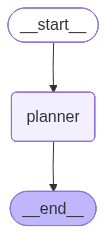

In [45]:
planner_app

In [42]:
initial_state: ExecutorState = {
"user_query": """
Show me the average inter-well distance as a fraction of the  
the distance from Eartch to The Moon times 10000

""",
"general_knowledge": [],
"facts": [],
"plan": None,  # see note below
}

result = planner_app.invoke(initial_state)

result["plan"]

agent='planner' user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.' tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')]


Plan(agent='planner', user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.', tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')])

In [44]:
result

{'user_query': '\nShow me the average inter-well distance as a fraction of the  \nthe distance from Eartch to The Moon times 10000\n\n',
 'general_knowledge': [],
 'facts': [],
 'plan': Plan(agent='planner', user_intent='Calculate the average inter-well distance as a fraction of the Earth-Moon distance multiplied by 10,000.', tasks=[Task(tool='general_knowledge_agent', instruction='What is the average distance from Earth to the Moon in kilometers?'), Task(tool='project_structure_agent', instruction='Provide the total number of wells and their coordinates in the project to calculate inter-well distances.'), Task(tool='analyst_agent', instruction='Calculate the average inter-well distance using the well coordinates provided.'), Task(tool='derive_from_context', instruction='Using the average inter-well distance and the Earth-Moon distance, calculate the fraction of the inter-well distance to the Earth-Moon distance, multiplied by 10,000.')])}